In [28]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np
HERE = Path().resolve()
PROJECT_ROOT = next(p for p in [HERE, *HERE.parents] if (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT))

from src.io.obd_loader import load_obd_csv, require_columns
from src.io.timebase import add_elapsed_time
from src.physics.kinematics import add_speed_ms, add_acceleration
from src.physics.longitudinal import VehicleParams, add_longitudinal_forces
from src.physics.power_energy import add_power_terms, add_energy_terms
#from src.common.units import convert_mdot_air_to_kgs

In [29]:
from dataHandler import clean_obd_csv
from dataSmoother import smooth_csv_file

In [30]:
df1 = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_RT_S_Stau.csv")
# df2 = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_S_KA_Normal.csv")
# df3 = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-06_Seat_Leon_KA_KA_Normal.csv")

# df1copy = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_RT_S_Stau.csv")
# df2copy = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_S_KA_Normal.csv")
# df3copy = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-06_Seat_Leon_KA_KA_Normal.csv")




cleaned_data_path = clean_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_RT_S_Stau.csv")
df1 = load_obd_csv(cleaned_data_path)
df1['time']
df1.columns
require_columns(df1, ["time", "speed_kmh", "engine_rpm"])


# require_columns(df2, ["time", "speed_kmh", "engine_rpm"])
# require_columns(df3, ["time", "speed_kmh", "engine_rpm"])




df1 = add_elapsed_time(df1)
df1 = add_speed_ms(df1)
df1 = add_acceleration(df1)

# df2 = add_elapsed_time(df2)
# df2 = add_speed_ms(df2)
# df2 = add_acceleration(df2)

# df3 = add_elapsed_time(df3)
# df3 = add_speed_ms(df3)
# df3 = add_acceleration(df3)




params = VehicleParams(
    mass_kg=1300, Cd=0.3, area_m2=2.2, crr=0.012,
    tyre_radius_m=0.318, rho_air=1.17
)




df1 = add_longitudinal_forces(df1, params, grade_rad=0.0)
df1 = add_power_terms(df1)
df1 = add_energy_terms(df1)

# df2 = add_longitudinal_forces(df2, params, grade_rad=0.0)
# df2 = add_power_terms(df2)
# df2 = add_energy_terms(df2)

# df3 = add_longitudinal_forces(df3, params, grade_rad=0.0)
# df3 = add_power_terms(df3)
# df3 = add_energy_terms(df3)
#df = convert_mdot_air_to_kgs(df)

#print(df)


Loaded: 2017-07-05_Seat_Leon_RT_S_Stau.csv
Rows: 46,349 | Cols: 11

Header standardisation:
  - 'Time' -> 'timestamp'
  - 'Engine Coolant Temperature [Â°C]' -> 'coolant_temp'
  - 'Intake Manifold Absolute Pressure [kPa]' -> 'map_kpa'
  - 'Engine RPM [RPM]' -> 'engine_rpm'
  - 'Vehicle Speed Sensor [km/h]' -> 'vehicle_speed'
  - 'Intake Air Temperature [Â°C]' -> 'intake_temp'
  - 'Air Flow Rate from Mass Flow Sensor [g/s]' -> 'maf_gps'
  - 'Absolute Throttle Position [%]' -> 'throttle_pct'
  - 'Ambient Air Temperature [Â°C]' -> 'ambient_temp'
  - 'Accelerator Pedal Position D [%]' -> 'pedal_pct_d'
  - 'Accelerator Pedal Position E [%]' -> 'pedal_pct_e'

Removed rows with blanks: 9
Remaining rows: 46,340

Saved cleaned CSV: C:\Users\ecjg3\Downloads\DriveSim-AI-Lboro-Group-main\DriveSim-AI-Lboro-Group-main\data\KIT\2017-07-05_Seat_Leon_RT_S_Stau_clean.csv



In [31]:
AFR = 14.7
LHV = 43e6

In [32]:
df1["maf_kgps"] = df1["maf_gps"] / 100 
df1["mdot_fuel"] = df1["maf_kgps"]  / AFR
#df1["mdot_fuel"].head(100)

# df2["Air Flow Rate from Mass Flow Sensor [kg/s]"] = df2["Air Flow Rate from Mass Flow Sensor [g/s]"] / 100 
# df2["mdot_fuel"] = df2["Air Flow Rate from Mass Flow Sensor [kg/s]"]  / AFR
# #df2["mdot_fuel"].head(100)

# df3["Air Flow Rate from Mass Flow Sensor [kg/s]"] = df3["Air Flow Rate from Mass Flow Sensor [g/s]"] / 100 
# df3["mdot_fuel"] = df3["Air Flow Rate from Mass Flow Sensor [kg/s]"]  / AFR
#df["mdot_fuel"].head(100)

In [33]:
df1["Pfuel"]  = df1["mdot_fuel"] * LHV
# df2["Pfuel"]  = df2["mdot_fuel"] * LHV
# df3["Pfuel"]  = df3["mdot_fuel"] * LHV

In [34]:
df1["chemical_efficiency"] = df1["P_drive_W"] / df1["Pfuel"]
# df2["chemical_efficiency"] = df2["P_drive_W"] / df2["Pfuel"]
# df3["chemical_efficiency"] = df3["P_drive_W"] / df3["Pfuel"]

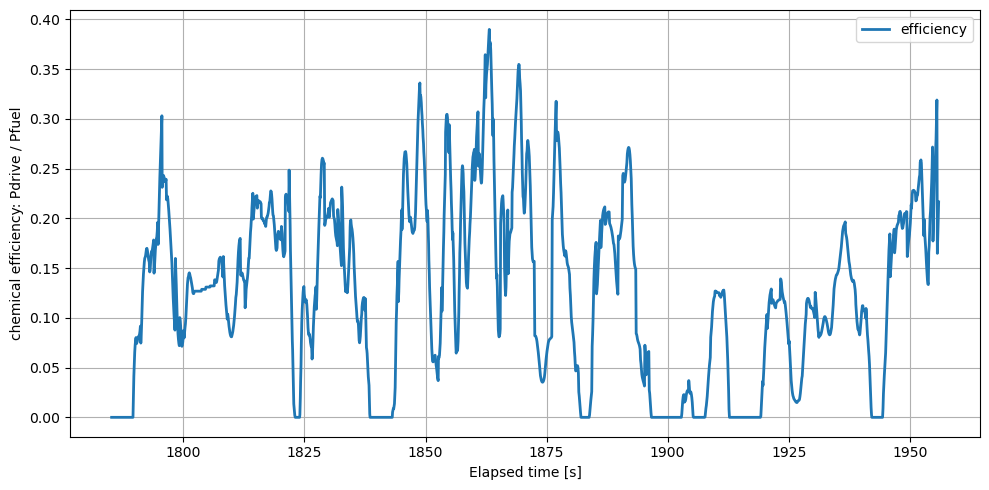

In [35]:
#sub = df1.iloc[:50000].copy()
sub = df1.iloc[21000:23000].copy()


plt.figure(figsize=(10,5))
plt.xlabel("Elapsed time [s]")
plt.ylabel("chemical efficiency: Pdrive / Pfuel")

plt.plot(sub["elapsed_time_s"], sub["chemical_efficiency"]*10, label="efficiency", linewidth=2)

plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [ ]:
#df1["chemical_efficiency"].equals(df2["chemical_efficiency"])

### importing 3 datasets

In [ ]:
#combining


# combined = pd.concat([df1copy, df2copy, df3copy])
# combinedLong = pd.concat([df1, df2, df3])

In [ ]:
# combined.shape

In [ ]:
# combined["chemical_efficiency"] = combinedLong["chemical_efficiency"]
# combined = combined.sample(frac=1).reset_index(drop=True)

## eliminating time 

In [ ]:
#combined = combined.drop('time', axis=1)
#R = combined.drop('time', axis=1)   # features
R = combined.drop('time', axis=1)
R = R.dropna()
y = R["chemical_efficiency"]
R = R.drop('chemical_efficiency', axis=1)

#R["chemical_efficiency"]= combinedLong["chemical_efficiency"]  
#y = combinedLong['chemical_efficiency']                # label
#del combined['time']
#combined.columns
#combined.shape

In [ ]:
R.shape
#combined.columns

In [ ]:
#print(y)

In [ ]:
#print(R)

In [ ]:
y_np = y.to_numpy()
R_np = R.to_numpy()

In [ ]:
R_np
#y = y.sample(frac=1).reset_index(drop=True)

In [ ]:
split = int(0.8 * len(combined))

R_train, R_test = R_np[:split], R_np[split:]
y_train, y_test = y_np[:split], y_np[split:]

#  decoding 
ridge = Ridge(alpha=1e-3, fit_intercept=False)
ridge.fit(R_train, y_train)
y_pred = ridge.predict(R_test)

# MSE
mse = np.mean((y_test - y_pred)**2)
nrmse = np.sqrt(mse / np.var(y_test))

In [ ]:
print("ELM–TDM test")
print(f"MSE   = {mse:.4e}")
print(f"NRMSE = {nrmse:.4f}")

In [ ]:
#print(combined[:3])
plt.figure(figsize=(8,4))
plt.plot(y_test[:200], label="True")
plt.plot(y_pred[:200], label="Pred", linestyle="--")
plt.title("fuel efficiency approx ml")
plt.legend()
plt.show()

In [ ]:
array = [1, 5, 3 ,7, 4]
sorted_array = sorted(array)

In [ ]:
#traction limit test. 
vehicle_mass_kg = params.mass_kg
mu = 1
limit = mu*vehicle_mass_kg*9.81

if (df["F_trac_N"] > limit).any():
    print("A value exceeds the limit")
else:
    print("No values exceed the limit")